LEVEL:1 UNDERSTANDING THE DATA

In [4]:
import pandas as pd
df=pd.read_csv("Dataset1.csv")
df

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
...,...,...,...,...,...,...,...,...,...,...,...,...
186069,1,22439,NDLS,100,100,100,100,NEW DELHI,1,00:00:00,06:00:00,0
186070,2,22439,UMB,1095,896,697,1095,AMBALA CANT JN,1,08:08:00,08:10:00,199
186071,3,22439,LDH,1660,1348,1036,1660,LUDHIANA JN,1,09:19:00,09:21:00,312
186072,4,22439,JAT,2985,2408,1831,2985,JAMMU TAWI,1,12:38:00,12:40:00,577


In [6]:
#Total records and columns

print("Total records:",df.shape[0])
print("Total columns:",df.shape[1])

print("\ncolumn names:")
print(df.columns.tolist())

Total records: 186074
Total columns: 12

column names:
['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']


In [7]:
# Train-wise starting and ending stations

df = df.sort_values(["Train_No", "Route_Number"])

train_table = df.groupby("Train_No").agg(
    Starting_Station=("Station_Name", "first"),
    Ending_Station=("Station_Name", "last")
).reset_index()

display(train_table)

,Train_No,Starting_Station,Ending_Station
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.
...,...,...,...
11108,99904,PUNE JN.,TALEGAON
11109,99905,TALEGAON,SHIVAJINAGAR
11110,99906,PUNE JN.,TALEGAON
11111,99907,TALEGAON,PUNE JN.


In [8]:
#Distance statistics

print("Distance statistics:")
display(df["Distance"].describe())

Distance statistics:


count    186074.000000
mean        281.353838
std         483.743964
min           0.000000
25%          23.000000
50%          73.000000
75%         291.000000
max        4260.000000
Name: Distance, dtype: float64

In [9]:
#number of stops
stops=df.groupby("Train_No")["Station_Name"].count() - 1
print("Number of stops:")
print(stops.describe())

Number of stops:
count    11113.000000
mean        15.743814
std         12.993123
min          1.000000
25%          7.000000
50%         14.000000
75%         21.000000
max        117.000000
Name: Station_Name, dtype: float64


In [10]:
# missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


In [11]:
# duplicate values
print("Number of duplicate rows:")
df.duplicated().sum()

Number of duplicate rows:


np.int64(0)

In [12]:
#checking incorrect distance values
print(df["Distance"].min())

0


LEVEL:2 DATA CLEANING AND FEATURE CREATION

In [13]:
#remove duplicate rows
print("Duplicates removed")
print("Total rows:",len(df))

Duplicates removed
Total rows: 186074


In [14]:
#checking missing values
print(df.isnull().sum())

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


In [15]:
print(df.columns.tolist())
display(df[["Arrival_time","Departure_Time"]].head())

['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']


,Arrival_time,Departure_Time
0,00:00:00,10:25:00
1,11:06:00,11:08:00
2,11:28:00,11:30:00
3,12:10:00,00:00:00
4,00:00:00,20:30:00


In [16]:
# Convert time into minutes

df["Departure_Minutes"] = (
    pd.to_datetime(df["Departure_Time"], format="%H:%M:%S").dt.hour * 60
    + pd.to_datetime(df["Departure_Time"], format="%H:%M:%S").dt.minute
)

df["Arrival_Minutes"] = (
    pd.to_datetime(df["Arrival_time"], format="%H:%M:%S").dt.hour * 60
    + pd.to_datetime(df["Arrival_time"], format="%H:%M:%S").dt.minute
)

print(df.head())

   SN  Train_No Station_Code   1A   2A   3A   SL  Station_Name  Route_Number  \
0   1       107          SWV  100  100  100  100  SAWANTWADI R             1   
1   2       107         THVM  260  228  196  164        THIVIM             1   
2   3       107         KRMI  345  296  247  198       KARMALI             1   
3   4       107          MAO  490  412  334  256   MADGOAN JN.             1   
4   1       108          MAO  100  100  100  100   MADGOAN JN.             1   

  Arrival_time Departure_Time  Distance  Departure_Minutes  Arrival_Minutes  
0     00:00:00       10:25:00         0                625                0  
1     11:06:00       11:08:00        32                668              666  
2     11:28:00       11:30:00        49                690              688  
3     12:10:00       00:00:00        78                  0              730  
4     00:00:00       20:30:00         0               1230                0  


In [17]:
print(df[["Departure_Time","Departure_Minutes"]].head())
print(df[["Arrival_time","Arrival_Minutes"]].head())

  Departure_Time  Departure_Minutes
0       10:25:00                625
1       11:08:00                668
2       11:30:00                690
3       00:00:00                  0
4       20:30:00               1230
  Arrival_time  Arrival_Minutes
0     00:00:00                0
1     11:06:00              666
2     11:28:00              688
3     12:10:00              730
4     00:00:00                0


In [18]:
#total journey duration
df["Journey_Duration"]=df["Arrival_Minutes"]-df["Departure_Minutes"]

df.loc[df["Journey_Duration"]<0,"Journey_Duration"]+=1440
print(df["Journey_Duration"].head(10)) 

0     815
1    1438
2    1438
3     730
4     210
5    1438
6    1438
7    1345
8       0
9    1438
Name: Journey_Duration, dtype: int32


In [19]:
#total nmbr of stops
df["Total_stops"]=df.groupby("Train_No")["Station_Name"].transform("count")-1
print(df[["Train_No","Station_Name", "Total_stops"]].head())

   Train_No  Station_Name  Total_stops
0       107  SAWANTWADI R            3
1       107        THIVIM            3
2       107       KARMALI            3
3       107   MADGOAN JN.            3
4       108   MADGOAN JN.            3


LEVEL 3: FEATURE ANALYSIS WITH VISUALS

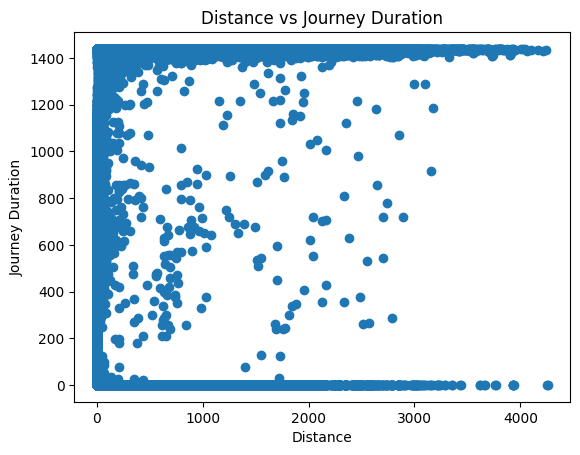

In [20]:
#visualize distane vs journey duration
import matplotlib.pyplot as plt
plt.scatter(df["Distance"],df["Journey_Duration"])
plt.xlabel("Distance")
plt.ylabel("Journey Duration")
plt.title("Distance vs Journey Duration")
plt.show()

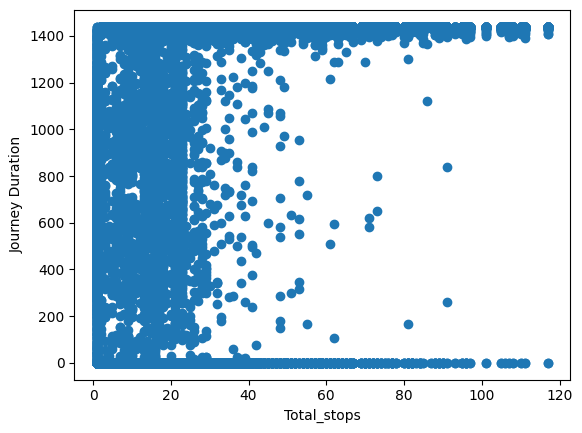

In [21]:
#nmbr of stops vs journey duration
plt.scatter(df["Total_stops"],df["Journey_Duration"])
plt.xlabel("Total_stops")
plt.ylabel("Journey Duration")
plt.show()

In [22]:
#correlation btwn features and journey duration
df[["Distance", "Total_stops","Journey_Duration"]].corr()

,Distance,Total_stops,Journey_Duration
Distance,1.000000,0.347306,0.069587
Total_stops,0.347306,1.000000,0.192472
Journey_Duration,0.069587,0.192472,1.000000


In [23]:
#pivot table for nmbr of stops by train 
pd.pivot_table(df,values="Total_stops",index="Train_No",aggfunc="mean")

,Total_stops
Train_No,
107,3.0
108,3.0
128,21.0
290,13.0
401,11.0
...,...
99904,11.0
99905,10.0
99906,11.0


LEVEL: 4 MODEL TRAINING AND EVALUATION

In [24]:
#create journey duration

df["Journey_Duration"]=df["Arrival_Minutes"]-df["Departure_Minutes"]
print(df[["Departure_Time","Arrival_time","Journey_Duration"]].head())

  Departure_Time Arrival_time  Journey_Duration
0       10:25:00     00:00:00              -625
1       11:08:00     11:06:00                -2
2       11:30:00     11:28:00                -2
3       00:00:00     12:10:00               730
4       20:30:00     00:00:00             -1230


In [25]:
#split the dataset into training and testing sets 
from sklearn.model_selection import train_test_split
x=df[["Distance","Total_stops"]]
y=df["Journey_Duration"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training data:",x_train.shape)
print("Testing data:",x_test.shape)

Training data: (148859, 2)
Testing data: (37215, 2)


In [27]:
#train a linear regression model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print("Model trained successfully")

Model trained successfully


In [30]:
#evaluate the model using MAE & RMSE
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np
y_pred=model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print("MAE:",mae)
print("RMSE:",rmse)

MAE: 21.259513497933565
RMSE: 136.21545425805


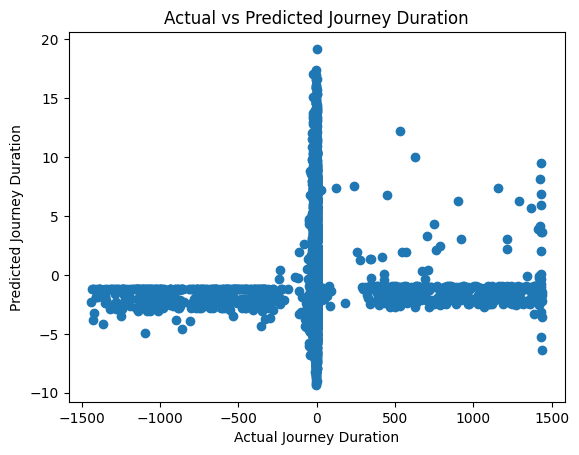

In [31]:
#actual vs predicted journey duration
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Journey Duration")
plt.ylabel("Predicted Journey Duration")
plt.title("Actual vs Predicted Journey Duration")
plt.show()

LEVEL: 5 MODEL COMPARISON AND USER TESTING

In [32]:
#train a basic model using only one input feature
x_basic=df[["Distance"]]
y=df["Journey_Duration"]
x_train_basic,x_test_basic,y_train_basic,y_test_basic=train_test_split(x_basic,y,test_size=0.2,random_state=42)

basic_model=LinearRegression()
basic_model.fit(x_train_basic,y_train_basic)
print("Basic model trained successfully")

Basic model trained successfully


In [34]:
#train an improved model using multiple input features
x_improved=df[["Distance","Total_stops"]]
y=df["Journey_Duration"]

x_train_improved,x_test_improved,y_train_improved,y_test_improved=train_test_split(x_improved,y,test_size=0.2,random_state=42)

improved_model=LinearRegression()
improved_model.fit(x_train_improved,y_train_improved)
print("Improved model trained successfully")

Improved model trained successfully


In [36]:
#Compare both models using MAE and RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
basic_pred = basic_model.predict(x_test_basic)
improved_pred = improved_model.predict(x_test_improved)

# Basic model errors
basic_mae = mean_absolute_error(y_test_basic, basic_pred)
basic_rmse = np.sqrt(mean_squared_error(y_test_basic, basic_pred))

# Improved model errors
improved_mae = mean_absolute_error(y_test_improved, improved_pred)
improved_rmse = np.sqrt(mean_squared_error(y_test_improved, improved_pred))

print("Basic Model")
print("MAE:", basic_mae)
print("RMSE:", basic_rmse)

print("\nImproved Model")
print("MAE:", improved_mae)
print("RMSE:", improved_rmse)

Basic Model
MAE: 21.21684707260737
RMSE: 136.2216099661253

Improved Model
MAE: 21.259513497933565
RMSE: 136.21545425805


In [38]:
#Select the better model
if improved_mae < basic_mae and improved_rmse < basic_rmse:
    print("Improved Model performs better")
else:
    print("Basic Model performs better")

Basic Model performs better


LEVEL: 6 FINAL INTREACTIVE MACHINE LEARNING PROJECT

In [40]:
# Level 6: Interactive Journey Duration Prediction

print("===== Journey Duration Prediction =====")

# Get input from user
distance = float(input("Enter Distance: "))
stops = int(input("Enter Total Stops: "))

# Create input data
new_data = [[distance, stops]]

# Predict journey duration
prediction = model.predict(new_data)

print("\nPredicted Journey Duration:", prediction[0], "minutes")

===== Journey Duration Prediction =====


Enter Distance:  500
Enter Total Stops:  10



Predicted Journey Duration: 0.9920038108270142 minutes


C:\Users\new\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
